# Smart Inventory & Reorder System
BAN 3110
Dataset: inventory_dataset.csv

# Colab 1 — Smart Inventory & Reorder System

A small inventory decision-support tool for a business (e.g., retail store, warehouse). It reads inventory + weekly sales, then applies business rules to label each item as REORDER, HOLD, or DISCONTINUE. It also calculates profit and profit margin, and visualizes current stock vs. reorder threshold so a manager can act quickly.


# Inventory Data Manipulation

In [43]:
import pandas as pd

In [44]:
csv_file_path = '/content/inventory_dataset.csv'

df = pd.read_csv(csv_file_path)

df

,product,category,stock,weekly_sales,cost,price
0,Wine A,Red,20,12,8,15
1,Wine B,White,60,4,5,12
2,Wine C,Red,15,10,7,14
3,Wine D,Sparkling,80,3,10,20
4,Wine E,White,10,9,6,13


In [46]:
# business rules
def inventory_decision(row):
    # Rule 1: If stock is less than 2 weeks of sales -> reorder
    if row['stock'] < row['weekly_sales'] * 2:
        return "REORDER"

    # Rule 2: If item sells very slowly but we have a lot of stock -> discontinue
    elif row['weekly_sales'] < 5 and row['stock'] > 50:
        return "DISCONTINUE"

    # otherwise -> hold
    else:
        return "HOLD"

df['decision'] = df.apply(inventory_decision, axis=1)
df

,product,category,stock,weekly_sales,cost,price,decision
0,Wine A,Red,20,12,8,15,REORDER
1,Wine B,White,60,4,5,12,DISCONTINUE
2,Wine C,Red,15,10,7,14,REORDER
3,Wine D,Sparkling,80,3,10,20,DISCONTINUE
4,Wine E,White,10,9,6,13,REORDER


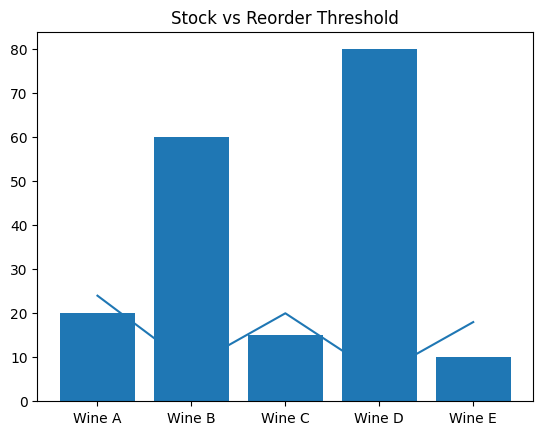

In [47]:
df['reorder_threshold'] = df['weekly_sales'] * 2

import matplotlib.pyplot as plt

plt.figure()
plt.bar(df['product'], df['stock'])
plt.plot(df['product'], df['reorder_threshold'])
plt.title("Stock vs Reorder Threshold")
plt.show()


In [48]:
df['unit_profit'] = df['price'] - df['cost']
df['margin_pct'] = ((df['unit_profit']/df['price']) * 100).round(1)
df

,product,category,stock,weekly_sales,cost,price,decision,reorder_threshold,unit_profit,margin_pct
0,Wine A,Red,20,12,8,15,REORDER,24,7,46.7
1,Wine B,White,60,4,5,12,DISCONTINUE,8,7,58.3
2,Wine C,Red,15,10,7,14,REORDER,20,7,50.0
3,Wine D,Sparkling,80,3,10,20,DISCONTINUE,6,10,50.0
4,Wine E,White,10,9,6,13,REORDER,18,7,53.8


# OpenAI Analysis and Insights


In [51]:
import os
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = "ADD KEY HERE"
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])


In [52]:
summary = df[['product','category','stock','weekly_sales','reorder_threshold','cost','price','unit_profit','margin_pct','decision']].to_string(index=False)

prompt = f"""
You are a supply chain inventory manager for an e-commerce business.
Given the inventory data, provide the following:
1) Top 3 products to REORDER and why
2) Top 2 products to DISCONTINUE and why
3) Any pricing or margin concerns you have noticed
4) 3 operational recommendations (re-order frequency, safety stock, promotional opportunities)

Inventory data:
{summary}
"""

response = client.responses.create(
    model="gpt-4o-mini",
    input=prompt

)

insights_text = response.output_text
print(insights_text)

Based on the provided inventory data, here are the insights and recommendations:

### 1) Top 3 Products to REORDER and Why
- **Wine A (Red)**:
  - **Stock**: 20 units
  - **Weekly Sales**: 12 units
  - **Reorder Threshold**: 24 units
  - **Reason**: Weekly sales are high relative to stock levels, suggesting a fast-moving product that will be out of stock soon. Reordering ensures customer demand is met.

- **Wine C (Red)**:
  - **Stock**: 15 units
  - **Weekly Sales**: 10 units
  - **Reorder Threshold**: 20 units
  - **Reason**: Similar to Wine A, Wine C's stock is low compared to its sales rate. Reordering will prevent stockouts and missed revenue opportunities.

- **Wine E (White)**:
  - **Stock**: 10 units
  - **Weekly Sales**: 9 units
  - **Reorder Threshold**: 18 units
  - **Reason**: Almost at stockout level given its high weekly sales. Reordering is necessary to maintain inventory and customer satisfaction.

### 2) Top 2 Products to DISCONTINUE and Why
- **Wine B (White)**:
  - *

# Google Docs and Sheets Output

In [53]:
from google.colab import auth
import gspread
from google.auth import default

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

In [54]:
from googleapiclient.discovery import build

docs_service = build('docs', 'v1', credentials=creds)
drive_service = build('drive', 'v3', credentials=creds)

In [55]:
# 1) Create the Document
doc_title = "Stock Report - Week 5"
doc = docs_service.documents().create(body={"title": doc_title}).execute()
doc_id = doc["documentId"]

# 2) Build the report text (you can customize this)
report_text = f"""
Stock Report

Context:
This stock report was generated using the inventory data and OpenAI analysis.
It focuses on reorder/discontinue actions and operational recommendations.doc

AI Insights:
{insights_text}
"""

# 3) Insert the text into the Doc
requests = [
    {
        "insertText": {
            "location": {"index": 1},
            "text": report_text
        }
    }
]

docs_service.documents().batchUpdate(
    documentId=doc_id,
    body={"requests": requests}
).execute()

print("Google Doc Created:")
print(f"https://docs.google.com/document/d/{doc_id}/edit")

Google Doc Created:
https://docs.google.com/document/d/1A5Ph8b7yc8pWIEYosO33O0CtKuUP0j4wSFEwQeOhfmo/edit


In [56]:
sh = gc.create('Stock Report') # name the report what you like
worksheet = sh.get_worksheet(0)

headers = ["product","category","stock","weekly_sales","reorder_threshold","cost","price","unit_profit","margin_pct","decision"]
worksheet.append_row(headers)

for _, r in df[headers].iterrows():
  worksheet.append_row(r.tolist())

print(f"All Done! You sheet is located at: {sh.url}")

All Done! You sheet is located at: https://docs.google.com/spreadsheets/d/1HePNOhsdQZyU8BLSuXbGj6duRZVnk3PNUx8PgJr0wdc
